<a href="https://colab.research.google.com/github/xyz-guy/AI-ML/blob/main/Notebooks/SignLanguage/SignLanguage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction**
#### In this series of experiments, we will train a CNN network on a dataset for Sign Language for Alphabets and will try to improve the accuracy with different techniques.

# **[Convolutional Neural Network (CNN)](https://en.wikipedia.org/wiki/Convolutional_neural_network)**

#### CNN is a deep learning algorithm specialised in image processing. Common Operations in CNN are
#### 1. Striding
#### 2. Convolution
#### 3. Pooling
#### 4. Flattening
#### 5. Feeding to Fully Connected Network

#### As our dataset is having image data, we have selected CNN as our solution algorithm.






# **Download Dataset**

In [3]:
! pip install -q kaggle

In [4]:
from google.colab import files
files.upload()

{}

In [5]:
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json
! kaggle datasets download datamunge/sign-language-mnist
! mkdir Sign_Language_MNIST
! unzip sign-language-mnist.zip -d Sign_Language_MNIST

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/datamunge/sign-language-mnist
License(s): CC0-1.0
100% 62.6M/62.6M [00:00<00:00, 128MB/s]

Archive:  sign-language-mnist.zip
  inflating: Sign_Language_MNIST/amer_sign2.png  
  inflating: Sign_Language_MNIST/amer_sign3.png  
  inflating: Sign_Language_MNIST/american_sign_language.PNG  
  inflating: Sign_Language_MNIST/sign_mnist_test.csv  
  inflating: Sign_Language_MNIST/sign_mnist_test/sign_mnist_test.csv  
  inflating: Sign_Language_MNIST/sign_mnist_train.csv  
  inflating: Sign_Language_MNIST/sign_mnist_train/sign_mnist_train.csv  


# **Import the libraries**
#### We will set the seed so that the initial random values set in the experiment will be same throughout the series. This will help in comparing the accuracies as we change the hyperparameters of the network

In [6]:
import random
import numpy as np
import tensorflow as tf

seed=7
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.config.experimental.enable_op_determinism()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# **Read and Pre-process the dataset into Train, Validate and Test dataset**

In [8]:
#Read Dataset files
train = pd.read_csv('Sign_Language_MNIST/sign_mnist_train.csv')
test = pd.read_csv('Sign_Language_MNIST/sign_mnist_test.csv')

#Covert to numpy array
train_set = np.array(train, dtype = 'float32')
test_set = np.array(test, dtype='float32')

#Specify class lables
class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y' ]

#Preprocess the dataset
X_train = train_set[:, 1:] / 255
y_train = train_set[:, 0]

X_test = test_set[:, 1:] / 255
y_test = test_set[:,0]

#Split training dataset into train and validation datasets
from sklearn.model_selection import train_test_split
X_train, X_validate, y_train, y_validate = train_test_split(X_train, y_train, test_size = 0.2, random_state = 12345)

#Reshape datasets
X_train = X_train.reshape(X_train.shape[0], *(28, 28, 1))
X_test = X_test.reshape(X_test.shape[0], *(28, 28, 1))
X_validate = X_validate.reshape(X_validate.shape[0], *(28, 28, 1))

# **Import Libraries for CNN**

In [9]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization,Activation
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from keras.callbacks import TensorBoard
from tensorflow.keras.callbacks import ReduceLROnPlateau

# **Defining the Convolutional Neural Network**

In [10]:
cnn_model = Sequential()

# Block 1
cnn_model.add(Conv2D(32, (3, 3), padding="same", input_shape=(28, 28, 1)))
cnn_model.add(BatchNormalization())
cnn_model.add(Activation('relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Dropout(0.2))

# Block 2
cnn_model.add(Conv2D(64, (3, 3), padding="same"))
cnn_model.add(BatchNormalization())
cnn_model.add(Activation('relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Dropout(0.3))

# Block 3
cnn_model.add(Conv2D(128, (3, 3), padding="same"))
cnn_model.add(BatchNormalization())
cnn_model.add(Activation('relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Dropout(0.4))

# Fully Connected Head
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(25, activation='softmax'))

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,377 (954.60 KB)

 Trainable params: 243,929 (952.85 KB)

 Non-trainable params: 448 (1.75 KB)

# **Training the Model**

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

#Setup Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False # Don't flip for sign language as hands are side-specific
)

# This stops training if validation loss doesn't improve for 7 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

optimizer = Adam(learning_rate=0.001) # Slightly lower rate for better stability
cnn_model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

history = cnn_model.fit(
    datagen.flow(X_train, y_train, batch_size=128),
    epochs=100,
    validation_data=(X_validate, y_validate),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.9502 - loss: 0.1517 - val_accuracy: 0.9816 - val_loss: 0.0483
Epoch 2/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.9506 - loss: 0.1476 - val_accuracy: 0.9953 - val_loss: 0.0171
Epoch 3/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.9537 - loss: 0.1391 - val_accuracy: 0.9887 - val_loss: 0.0375
Epoch 4/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.9546 - loss: 0.1403 - val_accuracy: 0.8099 - val_loss: 0.7877
Epoch 5/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.9604 - loss: 0.1222 - val_accuracy: 0.9971 - val_loss: 0.0103
Epoch 6/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.9617 - loss: 0.1171 - val_accuracy: 0.9663 - val_loss: 0.0938
Epoch 7/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.9654 - loss: 0.1082 - val_accuracy: 0.9967 - val_loss: 0.0093
Epoch 8/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.9660 - loss: 0.

# **Analysing the Performance**

Text(0.5, 1.0, 'Accuracy evolution')

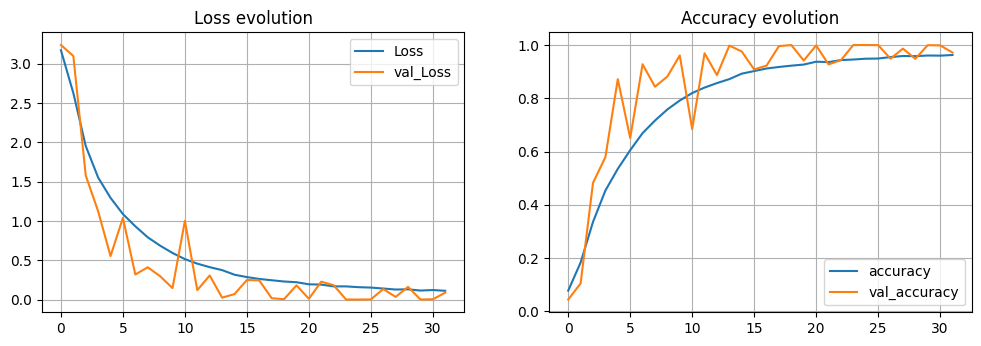

In [12]:
#Visualizing the training performance
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='val_Loss')
plt.legend()
plt.grid()
plt.title('Loss evolution')

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.grid()
plt.title('Accuracy evolution')

# **Analysing the Predictions**

In [13]:
#Predictions for the test data
predicted_classes=np.argmax(cnn_model.predict(X_test) ,axis=1)


225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


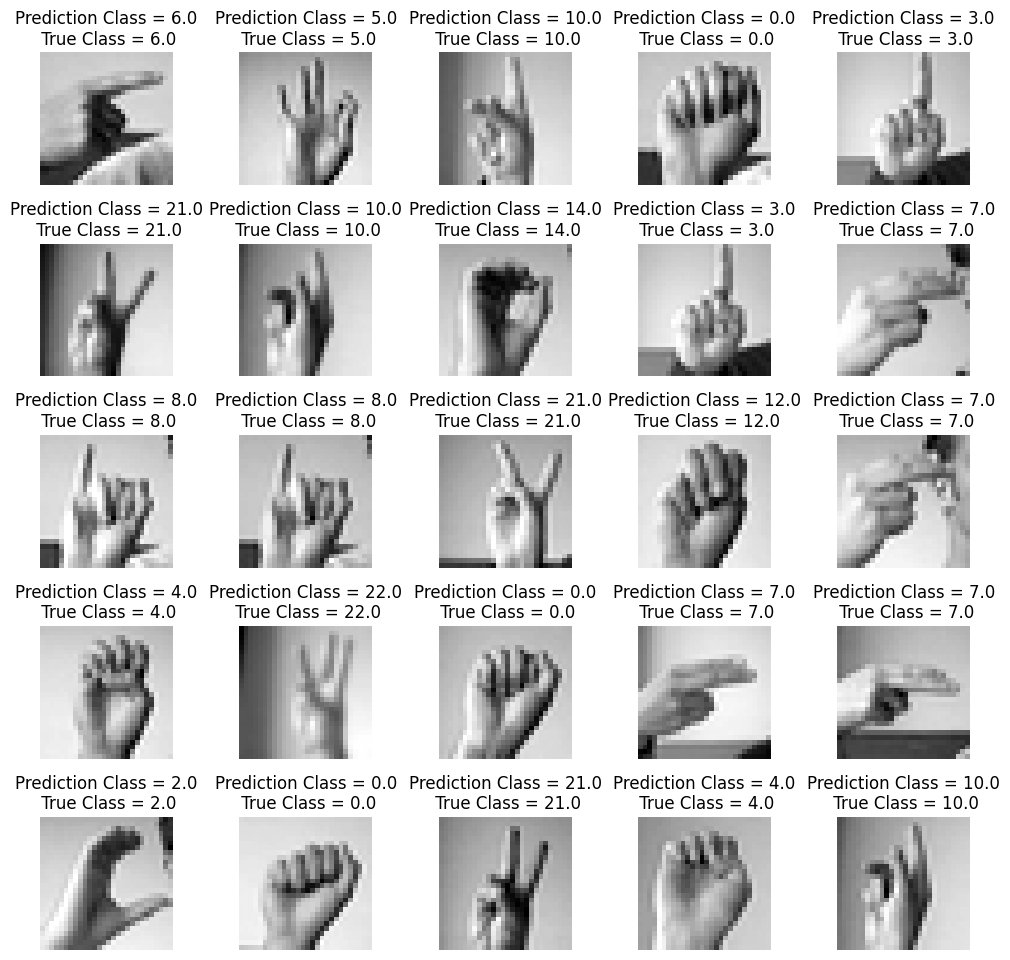

In [14]:
#Visualize predictions
L = 5
W = 5

fig, axes = plt.subplots(L, W, figsize = (12,12))
axes = axes.ravel()

for i in np.arange(0, L * W):
    axes[i].imshow(X_test[i].reshape(28,28), cmap='gray')
    axes[i].set_title(f"Prediction Class = {predicted_classes[i]:0.1f}\n True Class = {y_test[i]:0.1f}")
    axes[i].axis('off')
plt.subplots_adjust(wspace=0.5)

# **[Confusion Matrix](https://en.wikipedia.org/wiki/Confusion_matrix)**
#### [Confusion Matrix](https://en.wikipedia.org/wiki/Confusion_matrix) is used to define / visualize / summarise performance of a machine learning classification algorithm. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class.

 |          | Predicted Positive | Predicted Negative |
 | :-: | :-: |:-: |
 |Actual  Positive |    TP    |    FN    |
 | Actual Negative |    FP    |    TN    |


In [15]:
from sklearn.metrics import confusion_matrix
from sklearn import metrics
cm = metrics.confusion_matrix(y_test, predicted_classes)

In [16]:
#Defining function for confusion matrix plot
def plot_confusion_matrix(y_true,
                          y_pred,
                          classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues):
    if not title:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Computing confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

# Visualizing
    fig, ax = plt.subplots(figsize=(10, 10))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

   # Rotating the tick labels and setting their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")
    # Looping over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax
np.set_printoptions(precision=2)

Confusion matrix, without normalization


<Figure size 2000x2000 with 0 Axes>

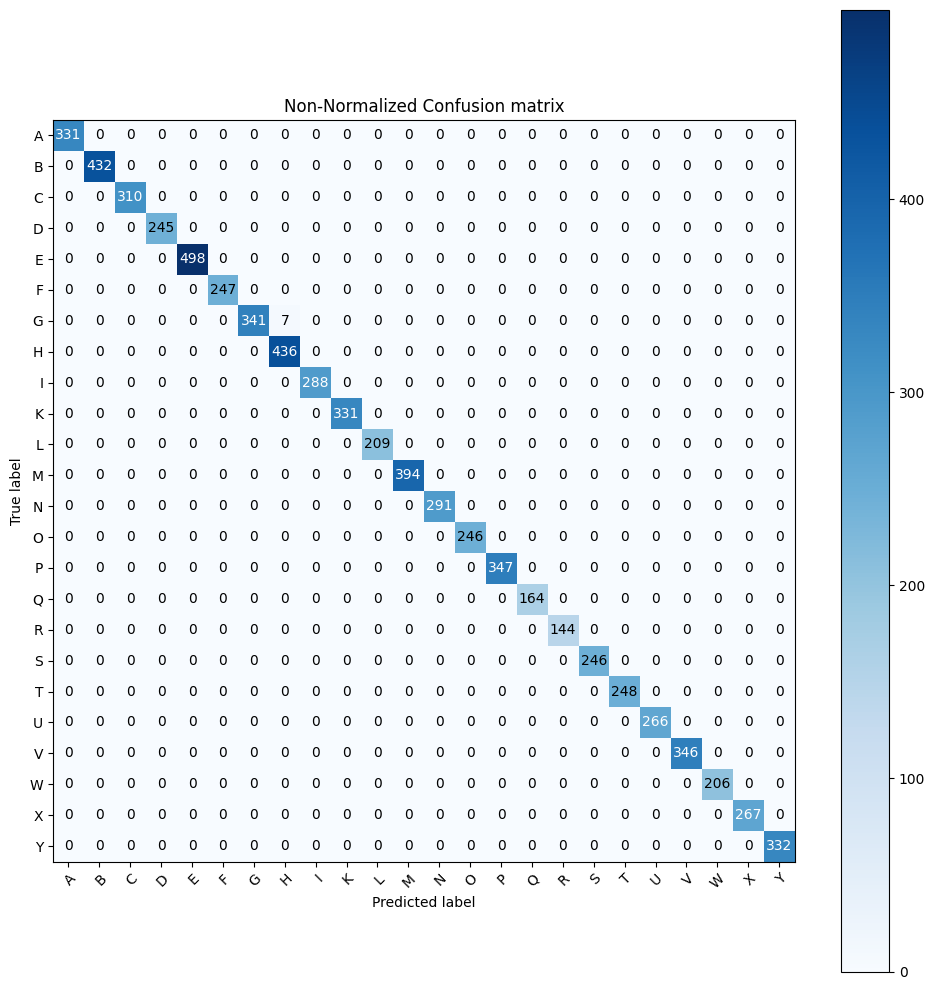

In [22]:
#Specifying class labels
class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y' ]

#Non-Normalized Confusion Matrix
plt.figure(figsize=(20,20))
plot_confusion_matrix(y_test, predicted_classes, classes = class_names, title='Non-Normalized Confusion matrix')
plt.show()

Normalized confusion matrix


<Figure size 3500x3500 with 0 Axes>

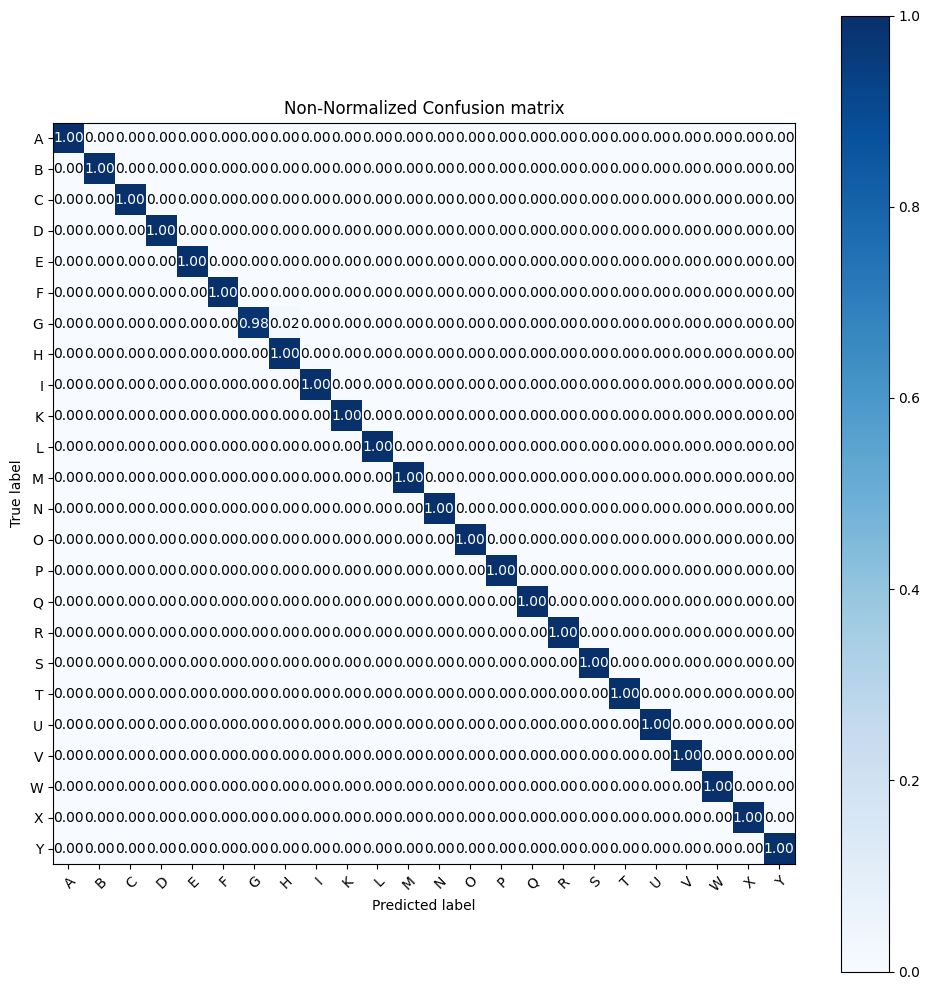

In [19]:
#Normalized Confusion Matrix
plt.figure(figsize=(35,35))
plot_confusion_matrix(y_test, predicted_classes, classes = class_names, normalize=True, title='Non-Normalized Confusion matrix')
plt.show()

# **Accuracy Calculation**

In [23]:
#Classification accuracy
from sklearn.metrics import accuracy_score
acc_score = accuracy_score(y_test, predicted_classes)
print('Accuracy Score = ',acc_score)

Accuracy Score =  0.9990239821528165


# **Conclusion**
#### The training and the validation accuracy (100%) is way larger than the testing accuracy (92.93%). This signifies that the model is overfitting.